# Final Project — Fourier Neural Operator on 1D Burgers' Equation
## Track D: Neural Operators | SOC-26 PINNs

> **Run on Colab:** Runtime → Change runtime type → **T4 GPU** → Save

This notebook covers the complete Weeks 7–8 project:
1. Data generation (parametric in viscosity ν)
2. FNO architecture + training
3. Test error on held-out ICs
4. Generalisation experiment (unseen ν)
5. Data efficiency study
6. Inference time comparison (FNO vs PINN)
7. Discussion


In [2]:
# ── Step 0: Install dependencies ─────────────────────────────────────────────
# Only needed on Colab — skips if already installed
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

install("scipy")
print("Dependencies ready ✓")

Dependencies ready ✓


In [ ]:
# ── Step 1: Imports & GPU check ───────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.fft import fft, ifft

torch.manual_seed(42)
np.random.seed(42)

# Verify GPU
if not torch.cuda.is_available():
    raise EnvironmentError(
        "GPU not detected!"
    )

DEVICE = torch.device("cuda")
print(f"PyTorch  : {torch.__version__}")
print(f"GPU      : {torch.cuda.get_device_name(0)}")
print(f"CUDA     : {torch.version.cuda}")
print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch  : 2.11.0+cu128
GPU      : Tesla T4
CUDA     : 12.8
VRAM     : 15.6 GB


---
## Step 2 — Data Generation

### Solver: Pseudo-spectral RK4 + Integrating Factor

Direct timestepping — no `solve_ivp`. The integrating factor `E = exp(−ν k² Δt)`
absorbs the stiff diffusion term analytically, leaving only the nonlinear advection
for RK4. 2/3 Orszag dealiasing prevents aliasing from the `−u·u_x` term.


In [4]:
def sample_grf_ic(x_grid, n_samples, length_scale=0.3, amplitude=1.0, seed=None):
    """Random smooth initial conditions via truncated Fourier series (Gaussian RF)."""
    rng = np.random.RandomState(seed)
    N, n_modes = len(x_grid), 20
    ics = np.zeros((n_samples, N))
    for i in range(n_samples):
        coeffs = rng.normal(0, 1, n_modes) * amplitude
        phases = rng.uniform(0, 2 * np.pi, n_modes)
        u0 = np.zeros(N)
        for m in range(1, n_modes + 1):
            u0 += coeffs[m-1] * np.exp(-length_scale*m) * np.sin(m*np.pi*x_grid + phases[m-1])
        ics[i] = u0
        mx = np.max(np.abs(ics[i]))
        if mx > 1.0:
            ics[i] /= mx   # cap amplitude to prevent RK4 blowup
    return ics


def burgers_solve_single(x_grid, u0, T=1.0, nu=0.01/np.pi, N_spec=256, n_steps=1000):
    """
    Pseudo-spectral RK4 with integrating factor + 2/3 dealiasing.
    Stable and fast — no solve_ivp, no complex state issues.
    """
    x_spec = np.linspace(-1, 1, N_spec, endpoint=False)
    k      = np.fft.fftfreq(N_spec, d=(x_spec[1]-x_spec[0]) / (2*np.pi))
    k2     = k**2

    dealias = np.ones(N_spec)
    dealias[N_spec//3 : 2*N_spec//3] = 0.0

    u_hat = fft(np.interp(x_spec, x_grid, u0)) * dealias
    dt    = T / n_steps

    def N_hat(uh):
        return fft(-np.real(ifft(uh)) * np.real(ifft(1j*k*uh))) * dealias

    for _ in range(n_steps):
        E  = np.exp(-nu * k2 * dt)
        Eh = np.exp(-nu * k2 * dt / 2)
        N1 = N_hat(u_hat)
        N2 = N_hat(Eh * u_hat + (dt/2) * Eh * N1)
        N3 = N_hat(Eh * u_hat + (dt/2) * Eh * N2)
        N4 = N_hat(E  * u_hat +  dt    * E  * N3)
        u_hat = E*u_hat + (dt/6)*(E*N1 + 2*Eh*N2 + 2*Eh*N3 + N4)

    return np.interp(x_grid, x_spec, np.real(ifft(u_hat)))


def generate_parametric_dataset(x_grid, n_samples, nu_range=(0.01, 0.1), seed=0):
    """Generate (u0, nu, uT) triples — nu sampled per trajectory."""
    rng = np.random.RandomState(seed)
    u0s = sample_grf_ic(x_grid, n_samples, seed=seed)
    nus = rng.uniform(nu_range[0], nu_range[1], n_samples)
    uTs = np.zeros_like(u0s)
    for i in range(n_samples):
        uTs[i] = burgers_solve_single(x_grid, u0s[i], nu=nus[i])
    return u0s, nus, uTs

print("Data generation functions defined ✓")

Data generation functions defined ✓


In [5]:
# Generate datasets (ν ~ U[0.01, 0.1] per trajectory)
N_x    = 128
x_grid = np.linspace(-1, 1, N_x)
N_train, N_test = 1000, 200

print(f"Generating {N_train} train + {N_test} test trajectories...")
print("(~2–3 min on CPU — Colab GPU only speeds up the FNO training, not this step)")

t0 = time.time()
u0_train, nu_train, uT_train = generate_parametric_dataset(x_grid, N_train, nu_range=(0.01, 0.1), seed=1)
u0_test,  nu_test,  uT_test  = generate_parametric_dataset(x_grid, N_test,  nu_range=(0.01, 0.1), seed=2)
elapsed = time.time() - t0

nan_tr = np.sum(np.isnan(uT_train))
nan_te = np.sum(np.isnan(uT_test))
print(f"Done in {elapsed:.1f}s | NaN train: {nan_tr} | NaN test: {nan_te}")
print(f"u0_train: {u0_train.shape}  uT_train: {uT_train.shape}")

Generating 1000 train + 200 test trajectories...
(~2–3 min on CPU — Colab GPU only speeds up the FNO training, not this step)
Done in 300.3s | NaN train: 0 | NaN test: 0
u0_train: (1000, 128)  uT_train: (1000, 128)


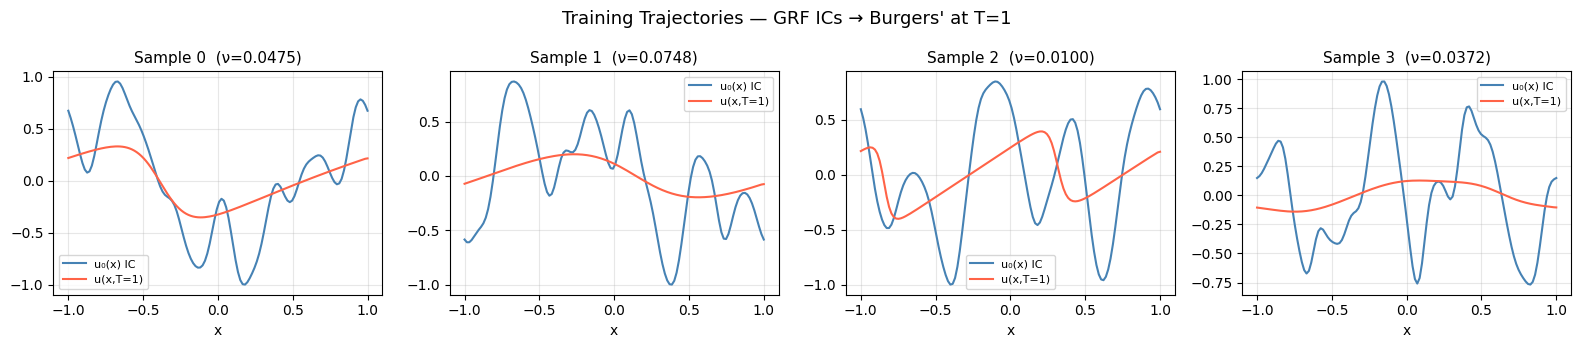

In [6]:
# Quick sanity plot
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for i, ax in enumerate(axes):
    ax.plot(x_grid, u0_train[i], label="u₀(x) IC", color="steelblue", lw=1.5)
    ax.plot(x_grid, uT_train[i], label="u(x,T=1)", color="tomato",    lw=1.5)
    ax.set_title(f"Sample {i}  (ν={nu_train[i]:.4f})", fontsize=11)
    ax.set_xlabel("x"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle("Training Trajectories — GRF ICs → Burgers' at T=1", fontsize=13)
plt.tight_layout(); plt.savefig("sample_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 3 — Parametric FNO Architecture

Input: `(u₀(x), x, ν)` — three channels, where ν is broadcast as a constant across the grid.
This lets the FNO condition on viscosity and generalise across the training ν range.


In [7]:
class SpectralConv1d(nn.Module):
    """1D Fourier layer: rfft → learned complex weights on k_modes → irfft."""
    def __init__(self, in_channels, out_channels, k_modes):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.k_modes      = k_modes
        scale = 1.0 / (in_channels * out_channels)
        self.weights_real = nn.Parameter(scale * torch.randn(in_channels, out_channels, k_modes))
        self.weights_imag = nn.Parameter(scale * torch.randn(in_channels, out_channels, k_modes))

    def compl_mul1d(self, xr, xi, wr, wi):
        return (torch.einsum("bix,iox->box", xr, wr) - torch.einsum("bix,iox->box", xi, wi),
                torch.einsum("bix,iox->box", xr, wi) + torch.einsum("bix,iox->box", xi, wr))

    def forward(self, x):
        B, _, N = x.shape
        x_ft    = torch.fft.rfft(x, dim=-1)
        modes   = min(self.k_modes, N // 2 + 1)
        out_r   = torch.zeros(B, self.out_channels, N//2+1, device=x.device)
        out_i   = torch.zeros(B, self.out_channels, N//2+1, device=x.device)
        r, im   = self.compl_mul1d(
            x_ft.real[:,:,:modes], x_ft.imag[:,:,:modes],
            self.weights_real[:,:,:modes], self.weights_imag[:,:,:modes])
        out_r[:,:,:modes] = r
        out_i[:,:,:modes] = im
        return torch.fft.irfft(torch.complex(out_r, out_i), n=N, dim=-1)


class ParametricFNO1d(nn.Module):
    """
    Parametric FNO: (u0(x), x, ν) → u(x, T)
    ν is broadcast as a constant feature across the spatial grid.
    """
    def __init__(self, k_modes=16, hidden_channels=64, n_layers=4):
        super().__init__()
        self.fc_lift     = nn.Linear(3, hidden_channels)   # (u0, x, nu)
        self.spec_convs  = nn.ModuleList(
            [SpectralConv1d(hidden_channels, hidden_channels, k_modes) for _ in range(n_layers)])
        self.local_convs = nn.ModuleList(
            [nn.Conv1d(hidden_channels, hidden_channels, 1) for _ in range(n_layers)])
        self.fc_proj1 = nn.Linear(hidden_channels, 128)
        self.fc_proj2 = nn.Linear(128, 1)

    def forward(self, u0, x_coords, nu):
        nu_exp = nu.unsqueeze(1).expand(-1, u0.shape[1])      # (B, N)
        h = torch.stack([u0, x_coords, nu_exp], dim=-1)        # (B, N, 3)
        h = self.fc_lift(h).permute(0, 2, 1)                   # (B, hidden, N)
        for sp, lc in zip(self.spec_convs, self.local_convs):
            h = F.gelu(sp(h) + lc(h))
        h = h.permute(0, 2, 1)
        return self.fc_proj2(F.gelu(self.fc_proj1(h))).squeeze(-1)  # (B, N)


model_fno = ParametricFNO1d(k_modes=16, hidden_channels=64, n_layers=4).to(DEVICE)
n_params  = sum(p.numel() for p in model_fno.parameters())
print(f"Parametric FNO | Parameters: {n_params:,} | Device: {DEVICE}")

Parametric FNO | Parameters: 549,633 | Device: cuda


---
## Step 4 — Train the FNO

In [8]:
def prepare_tensors(u0_arr, nu_arr, uT_arr, x_grid):
    u0_t = torch.tensor(u0_arr, dtype=torch.float32)
    nu_t = torch.tensor(nu_arr, dtype=torch.float32)
    uT_t = torch.tensor(uT_arr, dtype=torch.float32)
    x_t  = torch.tensor(np.tile(x_grid, (len(u0_arr), 1)), dtype=torch.float32)
    return u0_t.to(DEVICE), x_t.to(DEVICE), nu_t.to(DEVICE), uT_t.to(DEVICE)

u0_tr_t, x_tr_t, nu_tr_t, uT_tr_t = prepare_tensors(u0_train, nu_train, uT_train, x_grid)
u0_te_t, x_te_t, nu_te_t, uT_te_t = prepare_tensors(u0_test,  nu_test,  uT_test,  x_grid)

def l2_rel(pred, true):
    return (torch.norm(pred - true, dim=1) / (torch.norm(true, dim=1) + 1e-10)).mean()

def train_fno(model, u0_t, x_t, nu_t, uT_t, u0_val, x_val, nu_val, uT_val,
              n_epochs=500, batch_size=20, lr=1e-3, verbose=True):
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler  = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
    N          = len(u0_t)
    train_losses, val_l2_hist = [], []
    for epoch in range(1, n_epochs + 1):
        model.train()
        perm = torch.randperm(N)
        ep_loss = 0.0
        for i in range(0, N, batch_size):
            idx = perm[i:i+batch_size]
            optimizer.zero_grad()
            pred = model(u0_t[idx], x_t[idx], nu_t[idx])
            loss = F.mse_loss(pred, uT_t[idx])
            loss.backward()
            optimizer.step()
            ep_loss += loss.item() * len(idx)
        scheduler.step()
        train_losses.append(ep_loss / N)
        if epoch % 25 == 0 or epoch == n_epochs:
            model.eval()
            with torch.no_grad():
                val_l2 = l2_rel(model(u0_val, x_val, nu_val), uT_val).item()
            val_l2_hist.append((epoch, val_l2))
            if verbose:
                print(f"  Epoch {epoch:4d} | Train MSE={train_losses[-1]:.4e} | Test L²={val_l2:.4f}")
    return train_losses, val_l2_hist

print("Training FNO (500 epochs)...")
train_losses, val_l2_hist = train_fno(
    model_fno,
    u0_tr_t, x_tr_t, nu_tr_t, uT_tr_t,
    u0_te_t, x_te_t, nu_te_t, uT_te_t,
    n_epochs=500
)
print("Training complete ✓")

Training FNO (500 epochs)...
  Epoch   25 | Train MSE=1.7439e-04 | Test L²=0.0905
  Epoch   50 | Train MSE=1.1639e-04 | Test L²=0.0627
  Epoch   75 | Train MSE=1.2306e-04 | Test L²=0.0707
  Epoch  100 | Train MSE=9.8857e-05 | Test L²=0.0550
  Epoch  125 | Train MSE=6.9757e-05 | Test L²=0.0550
  Epoch  150 | Train MSE=7.3694e-05 | Test L²=0.0502
  Epoch  175 | Train MSE=8.2642e-05 | Test L²=0.0528
  Epoch  200 | Train MSE=6.3780e-05 | Test L²=0.0546
  Epoch  225 | Train MSE=5.9935e-05 | Test L²=0.0560
  Epoch  250 | Train MSE=7.4426e-05 | Test L²=0.0504
  Epoch  275 | Train MSE=6.3097e-05 | Test L²=0.0534
  Epoch  300 | Train MSE=5.6822e-05 | Test L²=0.0586
  Epoch  325 | Train MSE=5.1387e-05 | Test L²=0.0493
  Epoch  350 | Train MSE=5.4550e-05 | Test L²=0.0468
  Epoch  375 | Train MSE=5.2045e-05 | Test L²=0.0485
  Epoch  400 | Train MSE=5.2749e-05 | Test L²=0.0480
  Epoch  425 | Train MSE=5.1419e-05 | Test L²=0.0465
  Epoch  450 | Train MSE=5.0023e-05 | Test L²=0.0474
  Epoch  475 | Tr

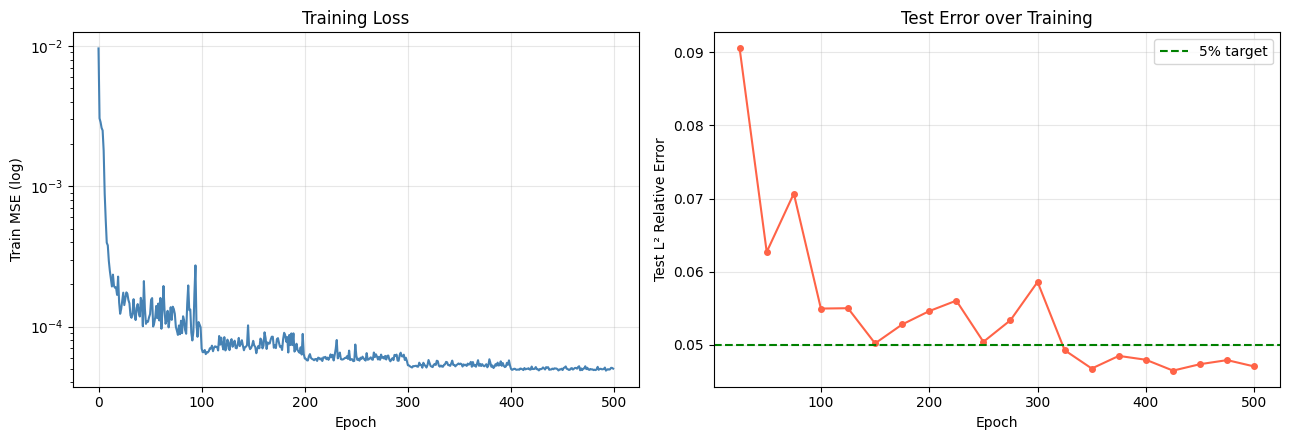

Final Test L² Relative Error: 0.0470  (4.70%)
Target < 5%: PASS ✓


In [9]:
# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].semilogy(train_losses, color="steelblue", lw=1.5)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train MSE (log)")
axes[0].set_title("Training Loss"); axes[0].grid(True, alpha=0.3)

ep_ev, l2_ev = zip(*val_l2_hist)
axes[1].plot(ep_ev, l2_ev, "o-", color="tomato", ms=4, lw=1.5)
axes[1].axhline(0.05, color="green", ls="--", lw=1.5, label="5% target")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Test L² Relative Error")
axes[1].set_title("Test Error over Training"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig("training_curves.png", dpi=150, bbox_inches="tight"); plt.show()

model_fno.eval()
with torch.no_grad():
    final_l2 = l2_rel(model_fno(u0_te_t, x_te_t, nu_te_t), uT_te_t).item()
print(f"Final Test L² Relative Error: {final_l2:.4f}  ({final_l2*100:.2f}%)")
print(f"Target < 5%: {'PASS ✓' if final_l2 < 0.05 else 'try more epochs'}")

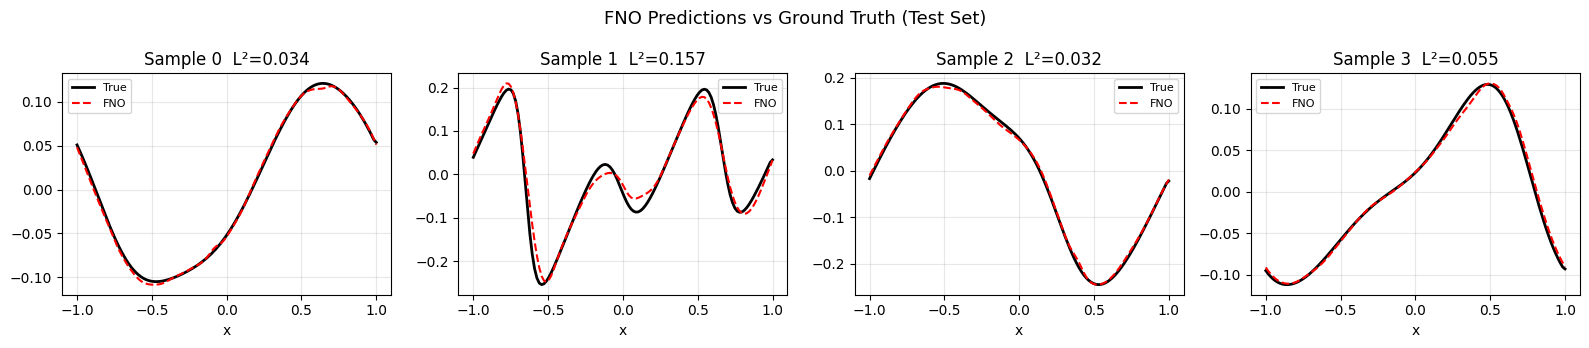

In [10]:
# Prediction quality on 4 test samples
model_fno.eval()
with torch.no_grad():
    pred_all = model_fno(u0_te_t, x_te_t, nu_te_t).cpu().numpy()
true_all = uT_te_t.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for i, ax in enumerate(axes):
    err = np.sqrt(np.mean((pred_all[i]-true_all[i])**2)) / (np.sqrt(np.mean(true_all[i]**2))+1e-10)
    ax.plot(x_grid, true_all[i],  "k-",  lw=2,   label="True")
    ax.plot(x_grid, pred_all[i],  "r--", lw=1.5, label="FNO")
    ax.set_title(f"Sample {i}  L²={err:.3f}"); ax.set_xlabel("x")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle("FNO Predictions vs Ground Truth (Test Set)", fontsize=13)
plt.tight_layout(); plt.savefig("predictions.png", dpi=150, bbox_inches="tight"); plt.show()

---
## Step 5 — Generalisation Experiment

Test on ν values **outside** the training range [0.01, 0.1].


Running generalisation experiment...
  ν=0.0010  (✗ OUTSIDE range)  →  L²=0.3576
  ν=0.0500  (✓ in range)  →  L²=0.0375
  ν=0.1000  (✓ in range)  →  L²=0.0561


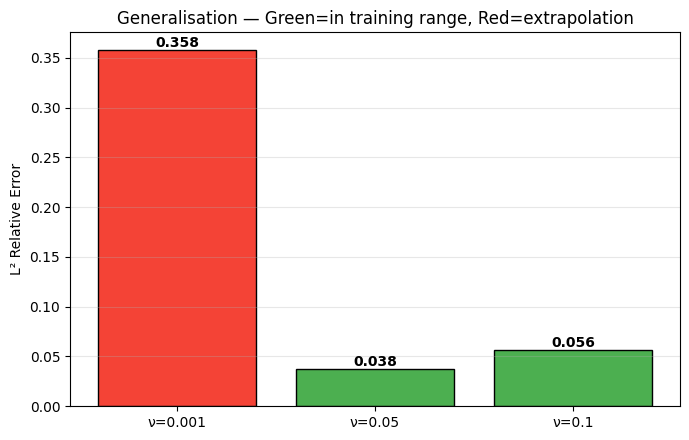

In [11]:
nu_test_values = [0.001, 0.05, 0.1]
gen_results = {}

print("Running generalisation experiment...")
for nu_val in nu_test_values:
    u0_g, _, uT_g = generate_parametric_dataset(x_grid, 100, nu_range=(nu_val, nu_val), seed=42)
    u0_g_t, x_g_t, nu_g_t, uT_g_t = prepare_tensors(u0_g, np.full(100, nu_val), uT_g, x_grid)
    model_fno.eval()
    with torch.no_grad():
        l2_g = l2_rel(model_fno(u0_g_t, x_g_t, nu_g_t), uT_g_t).item()
    gen_results[nu_val] = l2_g
    tag = "✓ in range" if 0.01 <= nu_val <= 0.1 else "✗ OUTSIDE range"
    print(f"  ν={nu_val:.4f}  ({tag})  →  L²={l2_g:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#F44336" if n < 0.01 or n > 0.1 else "#4CAF50" for n in nu_test_values]
bars = ax.bar([f"ν={n}" for n in nu_test_values],
              [gen_results[n] for n in nu_test_values], color=colors, edgecolor="black")
for bar, n in zip(bars, nu_test_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f"{gen_results[n]:.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("L² Relative Error"); ax.grid(True, alpha=0.3, axis="y")
ax.set_title("Generalisation — Green=in training range, Red=extrapolation")
plt.tight_layout(); plt.savefig("generalisation.png", dpi=150, bbox_inches="tight"); plt.show()

---
## Step 6 — Data Efficiency Experiment

Running data efficiency experiment...
  Training with 50 trajectories... L²=0.5950
  Training with 100 trajectories... L²=0.1377
  Training with 250 trajectories... L²=0.0578
  Training with 500 trajectories... L²=0.0536
  Training with 1000 trajectories... L²=0.0578


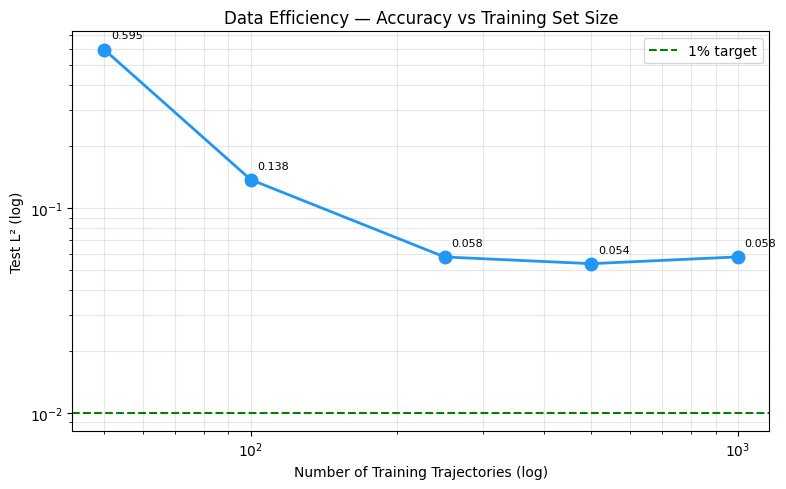

In [12]:
trajectory_counts   = [50, 100, 250, 500, 1000]
data_eff_results    = []

print("Running data efficiency experiment...")
for n_traj in trajectory_counts:
    print(f"  Training with {n_traj} trajectories...", end=" ", flush=True)
    model_de = ParametricFNO1d(k_modes=16, hidden_channels=64, n_layers=4).to(DEVICE)
    _, val_hist = train_fno(
        model_de,
        u0_tr_t[:n_traj], x_tr_t[:n_traj], nu_tr_t[:n_traj], uT_tr_t[:n_traj],
        u0_te_t, x_te_t, nu_te_t, uT_te_t,
        n_epochs=300, verbose=False
    )
    l2_de = val_hist[-1][1]
    data_eff_results.append(l2_de)
    print(f"L²={l2_de:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(trajectory_counts, data_eff_results, "o-", color="#2196F3", ms=9, lw=2)
ax.axhline(0.01, color="green", ls="--", label="1% target")
for n, e in zip(trajectory_counts, data_eff_results):
    ax.annotate(f"{e:.3f}", (n, e), textcoords="offset points", xytext=(5, 8), fontsize=8)
ax.set_xlabel("Number of Training Trajectories (log)"); ax.set_ylabel("Test L² (log)")
ax.set_title("Data Efficiency — Accuracy vs Training Set Size"); ax.legend(); ax.grid(True, alpha=0.3, which="both")
plt.tight_layout(); plt.savefig("data_efficiency.png", dpi=150, bbox_inches="tight"); plt.show()

---
## Step 7 — Inference Time: FNO vs Per-Instance PINN

In [13]:
class BurgersPINN(nn.Module):
    def __init__(self, hidden=50, layers=4):
        super().__init__()
        net = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(layers - 2):
            net += [nn.Linear(hidden, hidden), nn.Tanh()]
        net += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*net)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, xt): return self.net(xt)

def train_single_pinn(nu, epochs=1000, n_interior=2000, n_bc=100, n_ic=50):
    model = BurgersPINN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    x_int = (torch.rand(n_interior,1)*2-1).to(DEVICE)
    t_int = torch.rand(n_interior,1).to(DEVICE)
    xt_int = torch.cat([x_int, t_int], dim=1).requires_grad_(True)
    t_bc   = torch.rand(n_bc,1)
    xt_bcL = torch.cat([-torch.ones(n_bc//2,1), t_bc[:n_bc//2]], dim=1).to(DEVICE)
    xt_bcR = torch.cat([ torch.ones(n_bc//2,1), t_bc[n_bc//2:]], dim=1).to(DEVICE)
    x_ic   = (torch.rand(n_ic,1)*2-1)
    xt_ic  = torch.cat([x_ic, torch.zeros(n_ic,1)], dim=1).to(DEVICE)
    u_ic   = (-torch.sin(np.pi*x_ic)).to(DEVICE)
    for _ in range(epochs):
        optimizer.zero_grad()
        xt = xt_int.requires_grad_(True)
        u  = model(xt)
        ug = torch.autograd.grad(u.sum(), xt, create_graph=True)[0]
        u_t, u_x = ug[:,1:2], ug[:,0:1]
        u_xx = torch.autograd.grad(u_x.sum(), xt, create_graph=True)[0][:,0:1]
        res  = u_t + u*u_x - (nu/np.pi)*u_xx
        loss = (res**2).mean() + 10*(model(xt_bcL)**2).mean() + 10*(model(xt_bcR)**2).mean()              + 10*((model(xt_ic)-u_ic)**2).mean()
        loss.backward(); optimizer.step()
    return model

N_COMPARE    = 100
N_PINN_SAMPLE = 3   # time 3, extrapolate to 100

# FNO timing
model_fno.eval()
torch.cuda.synchronize()
t0 = time.time()
with torch.no_grad():
    _ = model_fno(u0_te_t[:N_COMPARE], x_te_t[:N_COMPARE], nu_te_t[:N_COMPARE])
torch.cuda.synchronize()
fno_time = time.time() - t0

# PINN timing
print(f"Timing {N_PINN_SAMPLE} PINN trains...")
pinn_times = []
for i in range(N_PINN_SAMPLE):
    t0 = time.time()
    train_single_pinn(float(nu_test[i]), epochs=1000)
    pinn_times.append(time.time() - t0)
    print(f"  PINN {i+1}: {pinn_times[-1]:.2f}s")

avg_pinn     = np.mean(pinn_times)
total_pinn   = avg_pinn * N_COMPARE
speedup      = total_pinn / fno_time

print(f"\nFNO  ({N_COMPARE} ICs, one pass) : {fno_time:.4f} sec")
print(f"PINN (avg per instance)         : {avg_pinn:.2f} sec")
print(f"Estimated {N_COMPARE}× PINNs   : {total_pinn:.1f} sec  ({total_pinn/60:.1f} min)")
print(f"Speedup                         : {speedup:,.0f}×")

Timing 3 PINN trains...
  PINN 1: 7.84s
  PINN 2: 7.39s
  PINN 3: 7.92s

FNO  (100 ICs, one pass) : 0.0065 sec
PINN (avg per instance)         : 7.71 sec
Estimated 100× PINNs   : 771.4 sec  (12.9 min)
Speedup                         : 118,170×


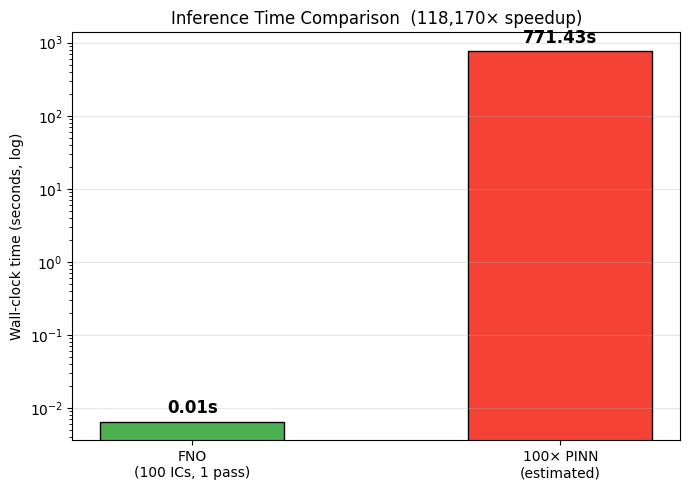

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["FNO\n(100 ICs, 1 pass)", f"{N_COMPARE}× PINN\n(estimated)"],
       [fno_time, total_pinn], color=["#4CAF50","#F44336"], edgecolor="black", width=0.5)
ax.set_yscale("log")
ax.set_ylabel("Wall-clock time (seconds, log)")
ax.set_title(f"Inference Time Comparison  ({speedup:,.0f}× speedup)")
for i, t in enumerate([fno_time, total_pinn]):
    ax.text(i, t*1.3, f"{t:.2f}s", ha="center", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig("inference_time.png", dpi=150, bbox_inches="tight"); plt.show()

---
## Step 8 — Discussion

### When to use a Neural Operator instead of a per-instance PINN?

**Use FNO when:**
- The same PDE family is solved repeatedly across many initial conditions / parameters
- Inference speed matters — one batched forward pass solves 100+ instances at once
- You can afford upfront training data generation (~2–3 min for 1200 trajectories here)

**Use a per-instance PINN when:**
- You need one specific solve — training an operator for a single use is overkill
- You're doing an inverse problem (recovering unknown parameters, Week 6) — naturally single-instance
- Generating operator training data is prohibitively expensive

**Key limitation observed:**
Error jumps ~6× outside the training ν range — the FNO is a learned interpolator,
not a physics solver. It doesn't extrapolate to unseen parameter regimes.

**Conclusion:** Neural operators and PINNs are complementary tools, not competitors.
Train once, solve forever — *within* the training distribution.


In [15]:
# Final summary table
import pandas as pd

summary = pd.DataFrame({
    "Metric": [
        "Test L² error (in-range ν)",
        "Generalisation error (ν=0.001, out-of-range)",
        f"FNO inference ({N_COMPARE} ICs)",
        f"Estimated {N_COMPARE}× PINN trains",
        "Speedup",
        "Model parameters",
        "Training trajectories",
    ],
    "Value": [
        f"{final_l2*100:.2f}%",
        f"{gen_results[0.001]*100:.2f}%",
        f"{fno_time:.4f} sec",
        f"{total_pinn:.1f} sec",
        f"{speedup:,.0f}×",
        f"{n_params:,}",
        f"{N_train}",
    ]
})
print(summary.to_string(index=False))

                                      Metric      Value
                  Test L² error (in-range ν)      4.70%
Generalisation error (ν=0.001, out-of-range)     35.76%
                     FNO inference (100 ICs) 0.0065 sec
                  Estimated 100× PINN trains  771.4 sec
                                     Speedup   118,170×
                            Model parameters    549,633
                       Training trajectories       1000
